# 4 Implementing a GPT model from scratch to generate text

In [28]:
GPT_CONFIG_124M = {
    "vocab_size": 50257, # Vocabulary size
    "context_length": 1024, # Context length
    "emb_dim": 768, # Embedding dimension
    "n_heads": 12, # Number of attention heads
    "n_layers": 12, # Number of layers
    "drop_rate": 0.1, # Dropout rate
    "qkv_bias": False # Query-Key-Value bias
}

In [37]:
import torch
import torch.nn as nn

class DummyGPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])
        self.trf_blocks = nn.Sequential(
            *[DummyTransformerBlock(cfg)
              for _ in range(cfg["n_layers"])]
        )
        self.final_norm = DummyLayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(
            cfg["emb_dim"], cfg["vocab_size"], bias=False
        )

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(
            torch.arange(seq_len, device=in_idx.device)
        )
        x = tok_embeds + pos_embeds
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits

class DummyTransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
    
    def forward(self, x):
        return x

class DummyLayerNorm(nn.Module):
    def __init__(self, normalized_shape, eps=1e-5):
        super().__init__()

    def forward(self, x):
        return x

In [38]:
import tiktoken

tokenizer = tiktoken.get_encoding("gpt2")
batch = []
txt1 = "Every effort moves you"
txt2 = "Every day holds a"

batch.append(torch.tensor(tokenizer.encode(txt1)))
batch.append(torch.tensor(tokenizer.encode(txt2)))
batch = torch.stack(batch, dim=0)
print(batch)

tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])


In [39]:
print(tokenizer.encode(txt1))

[6109, 3626, 6100, 345]


In [48]:
torch.manual_seed(123)
model = DummyGPTModel(GPT_CONFIG_124M)
logits = model(batch)
print("Output shape:", logits.shape)
print(logits)

Output shape: torch.Size([2, 4, 50257])
tensor([[[-1.2034,  0.3201, -0.7130,  ..., -1.5548, -0.2390, -0.4667],
         [-0.1192,  0.4539, -0.4432,  ...,  0.2392,  1.3469,  1.2430],
         [ 0.5307,  1.6720, -0.4695,  ...,  1.1966,  0.0111,  0.5835],
         [ 0.0139,  1.6754, -0.3388,  ...,  1.1586, -0.0435, -1.0400]],

        [[-1.0908,  0.1798, -0.9484,  ..., -1.6047,  0.2439, -0.4530],
         [-0.7860,  0.5581, -0.0610,  ...,  0.4835, -0.0077,  1.6621],
         [ 0.3567,  1.2698, -0.6398,  ..., -0.0162, -0.1296,  0.3717],
         [-0.2407, -0.7349, -0.5102,  ...,  2.0057, -0.3694,  0.1814]]],
       grad_fn=<UnsafeViewBackward0>)


In [61]:
logits[0][0]

tensor([-1.2034,  0.3201, -0.7130,  ..., -1.5548, -0.2390, -0.4667],
       grad_fn=<SelectBackward0>)

In [60]:
len(logits[0][0])

50257

In [63]:
max(logits[0][0])

tensor(3.5791, grad_fn=<UnbindBackward0>)

In [64]:
max(logits[1][0])

tensor(3.7974, grad_fn=<UnbindBackward0>)

In [65]:
min(logits[1][0])

tensor(-4.0774, grad_fn=<UnbindBackward0>)

In [66]:
torch.manual_seed(123)
batch_example = torch.randn(2, 5)
layer = nn.Sequential(nn.Linear(5, 6), nn.ReLU())
out = layer(batch_example)
print(out)

tensor([[0.2260, 0.3470, 0.0000, 0.2216, 0.0000, 0.0000],
        [0.2133, 0.2394, 0.0000, 0.5198, 0.3297, 0.0000]],
       grad_fn=<ReluBackward0>)


In [69]:
mean = out.mean(dim=-1, keepdim=True)
var = out.var(dim=-1, keepdim=True)
print("Mean:\n", mean)
print("Variance:\n", var)

Mean:
 tensor([[0.1324],
        [0.2170]], grad_fn=<MeanBackward1>)
Variance:
 tensor([[0.0231],
        [0.0398]], grad_fn=<VarBackward0>)


In [70]:
out_norm= (out - mean) / torch.sqrt(var)
mean = out_norm.mean(dim=-1, keepdim=True)
var = out_norm.var(dim=-1, keepdim=True)
print("Normalized layer outputs:\n", out_norm)
print("Mean:\n", mean)
print("Variance:\n", var)

Normalized layer outputs:
 tensor([[ 0.6159,  1.4126, -0.8719,  0.5872, -0.8719, -0.8719],
        [-0.0189,  0.1121, -1.0876,  1.5173,  0.5647, -1.0876]],
       grad_fn=<DivBackward0>)
Mean:
 tensor([[-5.9605e-08],
        [ 1.9868e-08]], grad_fn=<MeanBackward1>)
Variance:
 tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


In [71]:
torch.set_printoptions(sci_mode=False)
print("Mean:\n", mean)
print("Variance:\n", var)

Mean:
 tensor([[-0.0000],
        [ 0.0000]], grad_fn=<MeanBackward1>)
Variance:
 tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


In [94]:
# Listing 4.2 A layer normalization class

class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.eps = 1e-5
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        norm_x = (x - mean) / torch.sqrt(var + self.eps)
        return self.scale * norm_x + self.shift


In [ ]:
ln = LayerNorm(emb_dim=5)
out_ln = ln(batch_example)
mean = out_ln.mean(dim=-1, keepdim=True)
var = out_ln.var(dim=-1, unbiased=False, keepdim=True)
print("Mean:\n", mean)
print("Variance:\n", var)

Mean:
 tensor([[-0.0000],
        [ 0.0000]], grad_fn=<MeanBackward1>)
Variance:
 tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


### 4.3 Implementing a feed forward network with GELU activations

In [97]:
class GELU(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        return 0.5 * x * (1 + torch.tanh(
            torch.sqrt(torch.tensor(2.0 / torch.pi)) * (x + 0.044715 * torch.pow(x,3))
        ))

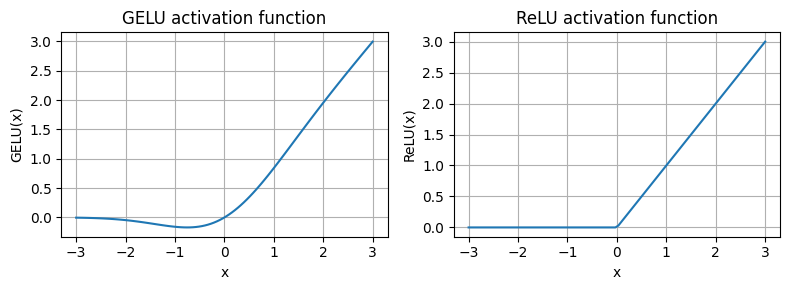

In [99]:
import matplotlib.pyplot as plt
gelu, relu = GELU(), nn.ReLU()

x = torch.linspace(-3, 3, 100)
y_gelu, y_relu = gelu(x), relu(x)
plt.figure(figsize=(8, 3))
for i, (y, label) in enumerate(zip([y_gelu, y_relu], ["GELU", "ReLU"]), 1):
    plt.subplot(1, 2, i)
    plt.plot(x, y)
    plt.title(f"{label} activation function")
    plt.xlabel("x")
    plt.ylabel(f"{label}(x)")
    plt.grid(True)
plt.tight_layout()
plt.show()


In [102]:
# 4.4 A feed forward neural network module

class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]), 
            GELU(),
            nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"])
        )

    def forward(self, x):
        return self.layers(x)

In [110]:
# 4.5 A neural network to illustrate shortcut connections

class ExampleDeepNeuralNetwork(nn.Module):
    def __init__(self, layer_sizes, use_shortcut):
        super().__init__()
        self.use_shortcut = use_shortcut
        self.layers = nn.ModuleList([
            nn.Sequential(nn.Linear(layer_sizes[0], layer_sizes[1]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[1], layer_sizes[2]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[2], layer_sizes[3]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[3], layer_sizes[4]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[4], layer_sizes[5]), GELU())
        ])

    def forward(self, x):
        for layer in self.layers:
            layer_output = layer(x)
            if self.use_shortcut and x.shape == layer_output.shape:
                x = x + layer_output
            else:
                x = layer_output
        return x

In [111]:
layer_sizes = [3, 3, 3, 3, 3, 1]
sample_input = torch.tensor([[1., 0., -1.]])
torch.manual_seed(123)
model_without_shortcut = ExampleDeepNeuralNetwork(
    layer_sizes, use_shortcut=False
)

In [112]:
def print_gradients(model, x):
    output = model(x)
    target = torch.tensor([[0.]])

    loss = nn.MSELoss()
    loss = loss(output, target)

    loss.backward()

    for name, param in model.named_parameters():
        if 'weight' in name:
            print(f"{name} has gradient mean of {param.grad.abs().mean().item()}")

In [113]:
print_gradients(model_without_shortcut, sample_input)

layers.0.0.weight has gradient mean of 0.00020173587836325169
layers.1.0.weight has gradient mean of 0.0001201116101583466
layers.2.0.weight has gradient mean of 0.0007152041071094573
layers.3.0.weight has gradient mean of 0.0013988735154271126
layers.4.0.weight has gradient mean of 0.005049645435065031


In [114]:
torch.manual_seed(123)
model_with_shortcut = ExampleDeepNeuralNetwork(
    layer_sizes, use_shortcut=True
)
print_gradients(model_with_shortcut, sample_input)

layers.0.0.weight has gradient mean of 0.22169791162014008
layers.1.0.weight has gradient mean of 0.20694106817245483
layers.2.0.weight has gradient mean of 0.32896995544433594
layers.3.0.weight has gradient mean of 0.2665732204914093
layers.4.0.weight has gradient mean of 1.3258540630340576


In [117]:
!python -m ensurepip --upgrade
!python -m pip install import-ipynb

Looking in links: /var/folders/xs/h7b_sr3j2c35lyrz1sgdwkpm0000gn/T/tmp9p8v1xz_
Processing /var/folders/xs/h7b_sr3j2c35lyrz1sgdwkpm0000gn/T/tmp9p8v1xz_/pip-24.0-py3-none-any.whl

[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: pip3 install --upgrade pip


In [125]:
!jupyter nbconvert --to script "/Users/dk/Desktop/Build a Large Language Model/ch03/ch03_coding_attention_mechanisms.ipynb"

[NbConvertApp] Converting notebook /Users/dk/Desktop/Build a Large Language Model/ch03/ch03_coding_attention_mechanisms.ipynb to script
[NbConvertApp] Writing 12733 bytes to /Users/dk/Desktop/Build a Large Language Model/ch03/ch03_coding_attention_mechanisms.py


In [127]:
import sys
sys.path.append('/Users/dk/Desktop/Build a Large Language Model/ch03')
from ch03_coding_attention_mechanisms import MultiHeadAttention

tensor([0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865])
Attention weights: tensor([0.1455, 0.2278, 0.2249, 0.1285, 0.1077, 0.1656])
Sum: tensor(1.0000)
Attention weights:  tensor([0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581])
Sum:  tensor(1.)
Attention weights:  tensor([0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581])
Sum:  tensor(1.)
tensor([0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581])
i =  0
x_i =  tensor([0.4300, 0.1500, 0.8900])
attn_weights_2[i] =  tensor(0.1385)
context_vec_2_tmp =  tensor([0.0596, 0.0208, 0.1233])


i =  1
x_i =  tensor([0.5500, 0.8700, 0.6600])
attn_weights_2[i] =  tensor(0.2379)
context_vec_2_tmp =  tensor([0.1308, 0.2070, 0.1570])


i =  2
x_i =  tensor([0.5700, 0.8500, 0.6400])
attn_weights_2[i] =  tensor(0.2333)
context_vec_2_tmp =  tensor([0.1330, 0.1983, 0.1493])


i =  3
x_i =  tensor([0.2200, 0.5800, 0.3300])
attn_weights_2[i] =  tensor(0.1240)
context_vec_2_tmp =  tensor([0.0273, 0.0719, 0.0409])


i =  4
x_i =  tensor([0.7700, 0.2500, 0.1000])

In [145]:
class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.att = MultiHeadAttention(
            d_in=cfg["emb_dim"],
            d_out=cfg["emb_dim"],
            context_length=cfg["context_length"],
            num_heads=cfg["n_heads"],
            dropout=cfg["drop_rate"],
            qkv_bias=cfg["qkv_bias"]
        )
        self.ff = FeedForward(cfg)
        self.norm1 = LayerNorm(cfg["emb_dim"])
        self.norm2 = LayerNorm(cfg["emb_dim"])
        self.drop_shortcut = nn.Dropout(cfg["drop_rate"])

    def forward(self, x):
        
        shortcut = x
        x = self.norm1(x)
        x = self.att(x)
        x = self.drop_shortcut(x)
        x = x + shortcut

        shortcut = x
        x = self.norm2(x)
        x = self.ff(x)
        x = self.drop_shortcut(x)
        x = x + shortcut
        return x

In [146]:
torch.manual_seed(123)
x = torch.rand(2, 4, 768)
block = TransformerBlock(GPT_CONFIG_124M)
output = block(x)

print("Input shape:", x.shape)
print("Output shape:", output.shape)

Input shape: torch.Size([2, 4, 768])
Output shape: torch.Size([2, 4, 768])


In [147]:
?TransformerBlock

Init signature: TransformerBlock(cfg)
Docstring:     
Base class for all neural network modules.

Your models should also subclass this class.

Modules can also contain other Modules, allowing them to be nested in
a tree structure. You can assign the submodules as regular attributes::

    import torch.nn as nn
    import torch.nn.functional as F


    class Model(nn.Module):
        def __init__(self) -> None:
            super().__init__()
            self.conv1 = nn.Conv2d(1, 20, 5)
            self.conv2 = nn.Conv2d(20, 20, 5)

        def forward(self, x):
            x = F.relu(self.conv1(x))
            return F.relu(self.conv2(x))

Submodules assigned in this way will be registered, and will also have their
parameters converted when you call :meth:`to`, etc.

.. note::
    As per the example above, an ``__init__()`` call to the parent class
    must be made before assignment on the child.

:ivar training: Boolean represents whether this module is in training or
                

In [148]:
??TransformerBlock

Init signature: TransformerBlock(cfg)
Docstring:     
Base class for all neural network modules.

Your models should also subclass this class.

Modules can also contain other Modules, allowing them to be nested in
a tree structure. You can assign the submodules as regular attributes::

    import torch.nn as nn
    import torch.nn.functional as F


    class Model(nn.Module):
        def __init__(self) -> None:
            super().__init__()
            self.conv1 = nn.Conv2d(1, 20, 5)
            self.conv2 = nn.Conv2d(20, 20, 5)

        def forward(self, x):
            x = F.relu(self.conv1(x))
            return F.relu(self.conv2(x))

Submodules assigned in this way will be registered, and will also have their
parameters converted when you call :meth:`to`, etc.

.. note::
    As per the example above, an ``__init__()`` call to the parent class
    must be made before assignment on the child.

:ivar training: Boolean represents whether this module is in training or
                

In [149]:
block = TransformerBlock(GPT_CONFIG_124M)
print(block)

TransformerBlock(
  (att): MultiHeadAttention(
    (W_query): Linear(in_features=768, out_features=768, bias=False)
    (W_key): Linear(in_features=768, out_features=768, bias=False)
    (W_value): Linear(in_features=768, out_features=768, bias=False)
    (out_proj): Linear(in_features=768, out_features=768, bias=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (ff): FeedForward(
    (layers): Sequential(
      (0): Linear(in_features=768, out_features=3072, bias=True)
      (1): GELU()
      (2): Linear(in_features=3072, out_features=768, bias=True)
    )
  )
  (norm1): LayerNorm()
  (norm2): LayerNorm()
  (drop_shortcut): Dropout(p=0.1, inplace=False)
)


In [150]:
GPT_CONFIG_124M

{'vocab_size': 50257,
 'context_length': 1024,
 'emb_dim': 768,
 'n_heads': 12,
 'n_layers': 12,
 'drop_rate': 0.1,
 'qkv_bias': False}

In [151]:
# 4.6 Coding the GPT model

class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])

        self.trf_blocks = nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])]
        )

        self.final_norm = LayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(
            cfg["emb_dim"], cfg["vocab_size"], bias=False
        )

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)

        pos_embeds = self.pos_emb(
            torch.arange(seq_len, device=in_idx.device)
        )
        x = tok_embeds + pos_embeds
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits

In [357]:
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)

out = model(batch)
print("Input batch:\n", batch)
print("\nOutput shape:", out.shape)
print(out)

Input batch:
 tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])

Output shape: torch.Size([2, 4, 50257])
tensor([[[ 0.3613,  0.4222, -0.0711,  ...,  0.3483,  0.4661, -0.2838],
         [-0.1792, -0.5660, -0.9485,  ...,  0.0477,  0.5181, -0.3168],
         [ 0.7120,  0.0332,  0.1085,  ...,  0.1018, -0.4327, -0.2553],
         [-1.0076,  0.3418, -0.1190,  ...,  0.7195,  0.4023,  0.0532]],

        [[-0.2564,  0.0900,  0.0335,  ...,  0.2659,  0.4454, -0.6806],
         [ 0.1230,  0.3653, -0.2074,  ...,  0.7705,  0.2710,  0.2246],
         [ 1.0558,  1.0318, -0.2800,  ...,  0.6936,  0.3205, -0.3178],
         [-0.1565,  0.3926,  0.3288,  ...,  1.2630, -0.1858,  0.0388]]],
       grad_fn=<UnsafeViewBackward0>)


In [156]:
total_params = sum(p.numel() for p in model.parameters())
print(f"Total number of parameters: {total_params:,}")

Total number of parameters: 163,009,536


In [ ]:
print("Token embedding layer shape:", model.tok_emb.weight.shape)
print("Output layer shape:", model.out_head.weight.shape)
print(f"Output number of trainable parameters: {model.out_head.weight.numel():,}")

Token embedding layer shape: torch.Size([50257, 768])
Output layer shape: torch.Size([50257, 768])
Output layer shape: 38,597,376


In [167]:
model.out_head.weight.numel()

38597376

In [164]:
total_params_gpt2 = (
    total_params - sum(p.numel()
    for p in model.out_head.parameters())
)
print(f"Number of trainable parameters " f"considering weight tying: {total_params_gpt2:,}")

Number of trainable parameters considering weight tying: 124,412,160


In [161]:
total_params

163009536

In [162]:
sum(p.numel()
    for p in model.out_head.parameters())

38597376

### Excercise 4.1 Number of parameters in feed forward and attention modules

In [181]:
model

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_feature

In [182]:
model.trf_blocks[0:1][0].att

MultiHeadAttention(
  (W_query): Linear(in_features=768, out_features=768, bias=False)
  (W_key): Linear(in_features=768, out_features=768, bias=False)
  (W_value): Linear(in_features=768, out_features=768, bias=False)
  (out_proj): Linear(in_features=768, out_features=768, bias=True)
  (dropout): Dropout(p=0.1, inplace=False)
)

In [191]:
model.trf_blocks[0:1][0].att

MultiHeadAttention(
  (W_query): Linear(in_features=768, out_features=768, bias=False)
  (W_key): Linear(in_features=768, out_features=768, bias=False)
  (W_value): Linear(in_features=768, out_features=768, bias=False)
  (out_proj): Linear(in_features=768, out_features=768, bias=True)
  (dropout): Dropout(p=0.1, inplace=False)
)

In [206]:
768*768*4

2359296

In [199]:
model.trf_blocks[0:1][0].att.parameters()

<generator object Module.parameters at 0x1181ec900>

In [198]:
sum(p.numel()
    for p in model.trf_blocks[0:1][0].att.parameters())

2360064

In [207]:
model.trf_blocks[0:1][0].ff.parameters()

<generator object Module.parameters at 0x1181efca0>

In [208]:
model.trf_blocks[0:1][0].ff.parameters

<bound method Module.parameters of FeedForward(
  (layers): Sequential(
    (0): Linear(in_features=768, out_features=3072, bias=True)
    (1): GELU()
    (2): Linear(in_features=3072, out_features=768, bias=True)
  )
)>

In [213]:
print(768*3072)
print(3072*768)
print(768*3072+3072*768)

2359296
2359296
4718592


In [212]:
sum(p.numel()
    for p in model.trf_blocks[0:1][0].ff.parameters())

4722432

In [220]:
type(model.trf_blocks)

torch.nn.modules.container.Sequential

In [233]:
model.trf_blocks

Sequential(
  (0): TransformerBlock(
    (att): MultiHeadAttention(
      (W_query): Linear(in_features=768, out_features=768, bias=False)
      (W_key): Linear(in_features=768, out_features=768, bias=False)
      (W_value): Linear(in_features=768, out_features=768, bias=False)
      (out_proj): Linear(in_features=768, out_features=768, bias=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (ff): FeedForward(
      (layers): Sequential(
        (0): Linear(in_features=768, out_features=3072, bias=True)
        (1): GELU()
        (2): Linear(in_features=3072, out_features=768, bias=True)
      )
    )
    (norm1): LayerNorm()
    (norm2): LayerNorm()
    (drop_shortcut): Dropout(p=0.1, inplace=False)
  )
  (1): TransformerBlock(
    (att): MultiHeadAttention(
      (W_query): Linear(in_features=768, out_features=768, bias=False)
      (W_key): Linear(in_features=768, out_features=768, bias=False)
      (W_value): Linear(in_features=768, out_features=768, bias=False)
      

In [247]:
model.trf_blocks[0].att.parameters

<bound method Module.parameters of MultiHeadAttention(
  (W_query): Linear(in_features=768, out_features=768, bias=False)
  (W_key): Linear(in_features=768, out_features=768, bias=False)
  (W_value): Linear(in_features=768, out_features=768, bias=False)
  (out_proj): Linear(in_features=768, out_features=768, bias=True)
  (dropout): Dropout(p=0.1, inplace=False)
)>

In [250]:
for block in model.trf_blocks:
    print(block.numel()
        for block in model.out_head.parameters())
    print(block.att)

<generator object <genexpr> at 0x1187c5ff0>
MultiHeadAttention(
  (W_query): Linear(in_features=768, out_features=768, bias=False)
  (W_key): Linear(in_features=768, out_features=768, bias=False)
  (W_value): Linear(in_features=768, out_features=768, bias=False)
  (out_proj): Linear(in_features=768, out_features=768, bias=True)
  (dropout): Dropout(p=0.1, inplace=False)
)
<generator object <genexpr> at 0x1187c5ff0>
MultiHeadAttention(
  (W_query): Linear(in_features=768, out_features=768, bias=False)
  (W_key): Linear(in_features=768, out_features=768, bias=False)
  (W_value): Linear(in_features=768, out_features=768, bias=False)
  (out_proj): Linear(in_features=768, out_features=768, bias=True)
  (dropout): Dropout(p=0.1, inplace=False)
)
<generator object <genexpr> at 0x1187c5ff0>
MultiHeadAttention(
  (W_query): Linear(in_features=768, out_features=768, bias=False)
  (W_key): Linear(in_features=768, out_features=768, bias=False)
  (W_value): Linear(in_features=768, out_features=768,

In [284]:
for block in model.trf_blocks:
    for weights in block.att.parameters():
        print(f"{(weights.numel()):,}")
        print(weights)
    print(block, "\n")
    print(block.att)

589,824
Parameter containing:
tensor([[ 0.0266,  0.0049, -0.0182,  ...,  0.0070, -0.0124, -0.0275],
        [ 0.0156, -0.0022, -0.0125,  ..., -0.0274,  0.0311,  0.0285],
        [ 0.0044, -0.0063, -0.0033,  ..., -0.0279, -0.0054, -0.0342],
        ...,
        [ 0.0150, -0.0191,  0.0103,  ..., -0.0287,  0.0078,  0.0257],
        [ 0.0301, -0.0164,  0.0020,  ...,  0.0142, -0.0351,  0.0306],
        [-0.0109, -0.0126, -0.0245,  ...,  0.0004,  0.0029,  0.0042]],
       requires_grad=True)
589,824
Parameter containing:
tensor([[-0.0115, -0.0161,  0.0170,  ..., -0.0193, -0.0269,  0.0054],
        [ 0.0125, -0.0345, -0.0224,  ..., -0.0216,  0.0346,  0.0022],
        [-0.0311, -0.0035, -0.0185,  ...,  0.0320,  0.0299, -0.0143],
        ...,
        [-0.0225, -0.0181,  0.0014,  ..., -0.0070,  0.0272,  0.0243],
        [ 0.0238, -0.0182, -0.0289,  ...,  0.0255, -0.0353,  0.0074],
        [-0.0251, -0.0006,  0.0302,  ..., -0.0309,  0.0350,  0.0207]],
       requires_grad=True)
589,824
Parameter 

In [228]:
len(model.trf_blocks)

12

In [ ]:
# manual path my guess is that we have 12 multi-head attention layers blocks, so if we know how many parameters one attention block has
# we can multiply that by 12 and that tells us how many parameters attention has in this case.
# Obviously it would be nicer to have a function to solve this more generally, but let's start with the manual approach

print(f"Parameters in a single MultiHeadAttention module: {768 * 768 * 4:,}")
print(f"Total parameters in all MultiHeadAttention modules: {768 * 768 * 4 * 12:,}")

Parameters in a single MultiHeadAttention module: 2,359,296
Total parameters in all MultiHeadAttention modules: 28,311,552


In [278]:
for block in model.trf_blocks:
    sum(block.numel()
        for block in model.out_head.parameters())
    print(block.att, "\n")
    print(block.att.parameters())

MultiHeadAttention(
  (W_query): Linear(in_features=768, out_features=768, bias=False)
  (W_key): Linear(in_features=768, out_features=768, bias=False)
  (W_value): Linear(in_features=768, out_features=768, bias=False)
  (out_proj): Linear(in_features=768, out_features=768, bias=True)
  (dropout): Dropout(p=0.1, inplace=False)
) 

<generator object Module.parameters at 0x1183e8ac0>
MultiHeadAttention(
  (W_query): Linear(in_features=768, out_features=768, bias=False)
  (W_key): Linear(in_features=768, out_features=768, bias=False)
  (W_value): Linear(in_features=768, out_features=768, bias=False)
  (out_proj): Linear(in_features=768, out_features=768, bias=True)
  (dropout): Dropout(p=0.1, inplace=False)
) 

<generator object Module.parameters at 0x1183e8ac0>
MultiHeadAttention(
  (W_query): Linear(in_features=768, out_features=768, bias=False)
  (W_key): Linear(in_features=768, out_features=768, bias=False)
  (W_value): Linear(in_features=768, out_features=768, bias=False)
  (out_proj

In [286]:
total = 0
for block in model.trf_blocks:
    for p in block.att.parameters():
        total += p.numel()

print(f"{total:,}")

28,320,768


In [338]:
# Bias at out_proj missing again in manual calculation

attn = model.trf_blocks[0].att
print(attn.W_query.weight.shape)
print(attn.W_query.bias)
print(attn.out_proj.weight.shape)
print(attn.out_proj.bias)
print(attn.out_proj.bias.shape)

torch.Size([768, 768])
None
torch.Size([768, 768])
Parameter containing:
tensor([-0.0119, -0.0170,  0.0257,  0.0052,  0.0259,  0.0279,  0.0081, -0.0217,
         0.0091, -0.0042,  0.0093,  0.0222, -0.0055, -0.0053, -0.0360, -0.0037,
         0.0020, -0.0019,  0.0173, -0.0062, -0.0164,  0.0079,  0.0108,  0.0100,
        -0.0313, -0.0201,  0.0196,  0.0343,  0.0114,  0.0080, -0.0200, -0.0280,
         0.0342,  0.0188,  0.0296, -0.0225, -0.0223,  0.0082,  0.0188, -0.0174,
         0.0214,  0.0347,  0.0047, -0.0086,  0.0024,  0.0118, -0.0329,  0.0288,
        -0.0176,  0.0328, -0.0308, -0.0134, -0.0041, -0.0174,  0.0245,  0.0359,
        -0.0238, -0.0244,  0.0281, -0.0328, -0.0078, -0.0343,  0.0178,  0.0042,
         0.0058,  0.0099,  0.0074, -0.0163,  0.0144,  0.0259,  0.0151,  0.0140,
        -0.0263,  0.0076,  0.0232, -0.0144, -0.0109,  0.0180, -0.0141, -0.0090,
        -0.0061, -0.0256, -0.0293, -0.0002,  0.0075,  0.0122, -0.0025, -0.0001,
        -0.0231, -0.0261, -0.0009, -0.0057,  0.

In [342]:
# okay looks like each out_proj has bias of 768 which makes sense because thats the number of columns on the out_proj

print(f"Parameters in a single MultiHeadAttention module: {768 * 768 * 4 + 768:,}")
print(f"Total parameters in all MultiHeadAttention modules: {(768 * 768 * 4 + 768) * 12:,}")

Parameters in a single MultiHeadAttention module: 2,360,064
Total parameters in all MultiHeadAttention modules: 28,320,768


In [340]:
model.trf_blocks

Sequential(
  (0): TransformerBlock(
    (att): MultiHeadAttention(
      (W_query): Linear(in_features=768, out_features=768, bias=False)
      (W_key): Linear(in_features=768, out_features=768, bias=False)
      (W_value): Linear(in_features=768, out_features=768, bias=False)
      (out_proj): Linear(in_features=768, out_features=768, bias=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (ff): FeedForward(
      (layers): Sequential(
        (0): Linear(in_features=768, out_features=3072, bias=True)
        (1): GELU()
        (2): Linear(in_features=3072, out_features=768, bias=True)
      )
    )
    (norm1): LayerNorm()
    (norm2): LayerNorm()
    (drop_shortcut): Dropout(p=0.1, inplace=False)
  )
  (1): TransformerBlock(
    (att): MultiHeadAttention(
      (W_query): Linear(in_features=768, out_features=768, bias=False)
      (W_key): Linear(in_features=768, out_features=768, bias=False)
      (W_value): Linear(in_features=768, out_features=768, bias=False)
      

In [258]:
model.trf_blocks[0].ff.parameters

<bound method Module.parameters of FeedForward(
  (layers): Sequential(
    (0): Linear(in_features=768, out_features=3072, bias=True)
    (1): GELU()
    (2): Linear(in_features=3072, out_features=768, bias=True)
  )
)>

In [267]:
print(f"Parameters in a single Feed Forward module: {768 * 3072 + 3072 * 768:,}", )
print(f"Total parameters in all Feed Forward modules: {(768 * 3072 + 3072 * 768) * 12:,}")

Parameters in a single Feed Forward module: 4,718,592
Total parameters in all Feed Forward modules: 56,623,104


In [287]:
total = 0
for block in model.trf_blocks:
    for p in block.ff.parameters():
        total += p.numel()

print(f"{total:,}")

56,669,184


In [311]:
# okay I guess in the manual calculation I did not consider bias. How do I manually consider the bias?

total = 0
for block in model.trf_blocks:
    for p in block.ff.parameters():
        print("len:", len(p))
        print("\nshape:", p.shape)
        total += p.numel()

print(f"{total:,}")

len: 3072

shape: torch.Size([3072, 768])
len: 3072

shape: torch.Size([3072])
len: 768

shape: torch.Size([768, 3072])
len: 768

shape: torch.Size([768])
len: 3072

shape: torch.Size([3072, 768])
len: 3072

shape: torch.Size([3072])
len: 768

shape: torch.Size([768, 3072])
len: 768

shape: torch.Size([768])
len: 3072

shape: torch.Size([3072, 768])
len: 3072

shape: torch.Size([3072])
len: 768

shape: torch.Size([768, 3072])
len: 768

shape: torch.Size([768])
len: 3072

shape: torch.Size([3072, 768])
len: 3072

shape: torch.Size([3072])
len: 768

shape: torch.Size([768, 3072])
len: 768

shape: torch.Size([768])
len: 3072

shape: torch.Size([3072, 768])
len: 3072

shape: torch.Size([3072])
len: 768

shape: torch.Size([768, 3072])
len: 768

shape: torch.Size([768])
len: 3072

shape: torch.Size([3072, 768])
len: 3072

shape: torch.Size([3072])
len: 768

shape: torch.Size([768, 3072])
len: 768

shape: torch.Size([768])
len: 3072

shape: torch.Size([3072, 768])
len: 3072

shape: torch.Size

In [322]:
print(model.trf_blocks[0].ff.layers)
print(model.trf_blocks[0].ff.layers[0])
print(model.trf_blocks[0].ff.layers[0].weight.shape)
print(model.trf_blocks[0].ff.layers[0].bias.shape)
print(model.trf_blocks[0].ff.layers[2].weight.shape)
print(model.trf_blocks[0].ff.layers[2].bias.shape)

Sequential(
  (0): Linear(in_features=768, out_features=3072, bias=True)
  (1): GELU()
  (2): Linear(in_features=3072, out_features=768, bias=True)
)
Linear(in_features=768, out_features=3072, bias=True)
torch.Size([3072, 768])
torch.Size([3072])
torch.Size([768, 3072])
torch.Size([768])


In [343]:
# I guess for the manual step we need to add the biases again

print(f"Parameters in a single Feed Forward module: {768 * 3072 + 3072 * 768 + 3072 + 768:,}", )
print(f"Total parameters in all Feed Forward modules: {(768 * 3072 + 3072 * 768 + 3072 + 768) * 12:,}")

Parameters in a single Feed Forward module: 4,722,432
Total parameters in all Feed Forward modules: 56,669,184


In [345]:
# okay so roughly 28m parameter in attention module, 46m parameter in the feed forward module
# so roughly 1/3 of the transformer block parameters are in the attention and 2/3 in the ff module
# and roughly 87m parameters are in the transformer block in total, which is roughly 2/3s of total parameters in this model (with weight tying)

In [351]:
total_size_bytes = total_params * 4
total_size_mb = total_size_bytes / (1024 * 1024)
print(f"Total size of the model: {total_size_mb:.2f} MB")

Total size of the model: 621.83 MB


### Excercise 4.2 Initializing larger GPT models

In [355]:
# setting up the different model GPT models hyperparameter

GPT_CONFIG_GPT_2_medium = {
    "vocab_size": 50257, # Vocabulary size
    "context_length": 1024, # Context length
    "emb_dim": 1024, # Embedding dimension
    "n_heads": 16, # Number of attention heads
    "n_layers": 24, # Number of layers
    "drop_rate": 0.1, # Dropout rate
    "qkv_bias": False # Query-Key-Value bias
}

GPT_CONFIG_GPT_2_large = {
    "vocab_size": 50257, # Vocabulary size
    "context_length": 1024, # Context length
    "emb_dim": 1280, # Embedding dimension
    "n_heads": 20, # Number of attention heads
    "n_layers": 36, # Number of layers
    "drop_rate": 0.1, # Dropout rate
    "qkv_bias": False # Query-Key-Value bias
}

GPT_CONFIG_GPT_2_xl = {
    "vocab_size": 50257, # Vocabulary size
    "context_length": 1024, # Context length
    "emb_dim": 1600, # Embedding dimension
    "n_heads": 25, # Number of attention heads
    "n_layers": 48, # Number of layers
    "drop_rate": 0.1, # Dropout rate
    "qkv_bias": False # Query-Key-Value bias
}

In [358]:
# Initialization of the different models

torch.manual_seed(123)
model_GPT_2_medium = GPTModel(GPT_CONFIG_GPT_2_medium)

out_GPT_2_medium = model_GPT_2_medium(batch)
print("Input batch:\n", batch)
print("\nOutput shape:", out_GPT_2_medium.shape)
print(out_GPT_2_medium)

Input batch:
 tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])

Output shape: torch.Size([2, 4, 50257])
tensor([[[ 0.5553,  0.4949,  0.3092,  ..., -0.2539, -0.3032,  0.2971],
         [ 0.3024, -0.0328, -0.5984,  ..., -0.6252, -0.5445, -0.9409],
         [ 0.4388,  0.3456, -0.2936,  ...,  0.5144,  0.0907,  0.0242],
         [ 0.1325,  0.6145, -0.8940,  ...,  0.3889,  0.0279, -0.5072]],

        [[ 1.0220,  0.3779,  0.8361,  ...,  0.1372, -0.2403,  0.8152],
         [ 0.0192,  0.3544, -0.5428,  ..., -0.0214,  0.0261, -0.4027],
         [ 0.2641,  0.1448, -0.3102,  ..., -0.0764, -0.4402,  0.2604],
         [ 0.6284,  1.2054, -0.6994,  ...,  0.0841, -0.3732, -0.1643]]],
       grad_fn=<UnsafeViewBackward0>)


In [359]:
torch.manual_seed(123)
model_GPT_2_large = GPTModel(GPT_CONFIG_GPT_2_large)

out_GPT_2_large = model_GPT_2_large(batch)
print("Input batch:\n", batch)
print("\nOutput shape:", out_GPT_2_large.shape)
print(out_GPT_2_large)

Input batch:
 tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])

Output shape: torch.Size([2, 4, 50257])
tensor([[[-0.1292, -0.3847,  0.2248,  ...,  0.5369,  0.3691, -0.7619],
         [ 0.4239,  0.2338, -1.0530,  ..., -0.0855, -0.6005, -0.4725],
         [ 0.2074, -0.6801, -0.0454,  ..., -1.2456, -0.8294, -0.0187],
         [ 0.4618, -0.2833, -0.4043,  ...,  0.0392, -0.5204, -0.2321]],

        [[-0.6438,  0.1008,  0.2805,  ...,  0.5632,  0.7455, -0.3469],
         [ 0.5257, -0.0004, -0.1389,  ..., -0.3714,  0.3727,  0.1004],
         [ 0.3873, -0.7259, -0.1061,  ..., -1.1120, -0.4745,  0.2956],
         [ 0.2372, -0.0430,  0.1782,  ..., -0.4974, -0.2305,  0.2401]]],
       grad_fn=<UnsafeViewBackward0>)


In [360]:
torch.manual_seed(123)
model_GPT_2_xl = GPTModel(GPT_CONFIG_GPT_2_xl)

out_GPT_2_xl = model_GPT_2_xl(batch)
print("Input batch:\n", batch)
print("\nOutput shape:", out_GPT_2_xl.shape)
print(out_GPT_2_xl)

Input batch:
 tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])

Output shape: torch.Size([2, 4, 50257])
tensor([[[-0.1291,  0.3885,  0.1057,  ...,  0.0180,  0.2309, -0.3901],
         [-0.2870, -0.0278, -0.3349,  ..., -0.0724,  0.1030, -0.3322],
         [-0.6001, -0.2720,  0.3672,  ...,  0.0804,  0.6928,  0.0880],
         [-1.3517, -0.3163,  0.2312,  ...,  0.3396, -0.0351,  0.3853]],

        [[-0.1893,  0.3246, -0.1917,  ..., -0.2170,  0.2229, -0.6889],
         [ 0.0024, -0.1743, -0.2006,  ...,  0.0684, -0.9490, -0.8778],
         [-0.0397,  0.0353,  0.2041,  ..., -0.3985,  0.1638, -0.2869],
         [-0.7979,  0.2167, -0.0873,  ...,  0.9055, -0.4025, -0.0753]]],
       grad_fn=<UnsafeViewBackward0>)


In [368]:
# bonus task - calculate total number of parameters on each GPT model

total_params = sum(p.numel() for p in model_GPT_2_medium.parameters())
print(f"Total number of parameters: {total_params:,}")

total_params_gpt2_medium = (
    total_params - sum(p.numel()
    for p in model_GPT_2_medium.out_head.parameters())
)
print(f"Number of trainable parameters " f"considering weight tying: {total_params_gpt2_medium:,}")

Total number of parameters: 406,212,608
Number of trainable parameters considering weight tying: 354,749,440


In [369]:
print("Token embedding layer shape:", model_GPT_2_medium.tok_emb.weight.shape)
print("Output layer shape:", model_GPT_2_medium.out_head.weight.shape)
print(f"Output number of trainable parameters: {model_GPT_2_medium.out_head.weight.numel():,}")

Token embedding layer shape: torch.Size([50257, 1024])
Output layer shape: torch.Size([50257, 1024])
Output number of trainable parameters: 51,463,168


In [370]:
total_params = sum(p.numel() for p in model_GPT_2_large.parameters())
print(f"Total number of parameters: {total_params:,}")

total_params_gpt2_large = (
    total_params - sum(p.numel()
    for p in model_GPT_2_large.out_head.parameters())
)
print(f"Number of trainable parameters " f"considering weight tying: {total_params_gpt2_large:,}")

Total number of parameters: 838,220,800
Number of trainable parameters considering weight tying: 773,891,840


In [371]:
print("Token embedding layer shape:", model_GPT_2_large.tok_emb.weight.shape)
print("Output layer shape:", model_GPT_2_large.out_head.weight.shape)
print(f"Output number of trainable parameters: {model_GPT_2_large.out_head.weight.numel():,}")

Token embedding layer shape: torch.Size([50257, 1280])
Output layer shape: torch.Size([50257, 1280])
Output number of trainable parameters: 64,328,960


In [372]:
total_params = sum(p.numel() for p in model_GPT_2_xl.parameters())
print(f"Total number of parameters: {total_params:,}")

total_params_gpt2_xl = (
    total_params - sum(p.numel()
    for p in model_GPT_2_xl.out_head.parameters())
)
print(f"Number of trainable parameters " f"considering weight tying: {total_params_gpt2_xl:,}")

Total number of parameters: 1,637,792,000
Number of trainable parameters considering weight tying: 1,557,380,800


In [373]:
print("Token embedding layer shape:", model_GPT_2_xl.tok_emb.weight.shape)
print("Output layer shape:", model_GPT_2_xl.out_head.weight.shape)
print(f"Output number of trainable parameters: {model_GPT_2_xl.out_head.weight.numel():,}")

Token embedding layer shape: torch.Size([50257, 1600])
Output layer shape: torch.Size([50257, 1600])
Output number of trainable parameters: 80,411,200


### 4.7 Generating text

In [377]:
def generate_text_simple(model, idx, max_new_tokens, context_size):
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -context_size:]
        with torch.no_grad():
            logits = model(idx_cond)
            
        logits = logits[:, -1, :]
        probas = torch.softmax(logits, dim=-1)
        idx_next = torch.argmax(probas, dim=-1, keepdim=True)
        idx = torch.cat((idx, idx_next), dim=1)
    
    return idx

In [402]:
start_context = "Hello, I am"
encoded = tokenizer.encode(start_context)
print("encoded:", encoded)
encoded_tensor = torch.tensor(encoded).unsqueeze(0)
print("encoded_tensor.shape:", encoded_tensor.shape)


encoded: [15496, 11, 314, 716]
encoded_tensor.shape: torch.Size([1, 4])


In [403]:
output_test = generate_text_simple(model, encoded_tensor, 5, 5)

In [404]:
print(output_test)

tensor([[15496,    11,   314,   716, 27018, 24086, 29289, 24306, 33528]])


In [405]:
output_test[0]

tensor([15496,    11,   314,   716, 27018, 24086, 29289, 24306, 33528])

In [406]:
print(tokenizer.decode(output_test[0].tolist()))

Hello, I am Featureimanlayer MessengerInvestigators


In [411]:
model.eval()
out = generate_text_simple(
    model=model,
    idx=encoded_tensor,
    max_new_tokens=6,
    context_size=GPT_CONFIG_124M["context_length"]
)
print("Output:", out)
print("Output length:", len(out[0]))

Output: tensor([[15496,    11,   314,   716, 27018, 24086, 47843, 30961, 42348,  7267]])
Output length: 10


In [412]:
print(tokenizer.decode(out[0].tolist()))

Hello, I am Featureiman Byeswickattribute argue


In [415]:
decoded_text = tokenizer.decode(out.squeeze(0).tolist())
print(decoded_text)

Hello, I am Featureiman Byeswickattribute argue
